In [1]:
using Plots

In [2]:
# --- Paraméterek -----------------------------------------------------------
a = 1.0          # belső sugár
b = 2.0          # külső sugár
Q = 1.0          # eredő nyíróerő (skálázásra jó)

# konstans a képletből
D = b^2 - a^2 - (a^2 + b^2) * log(b / a)

# --- Feszültségfüggvények --------------------------------------------------
function sigma_r(r, φ)
    return (Q / D) * (-r + (a^2 + b^2) / r - (a^2 * b^2) / r^3) * sin(φ)
end

function sigma_phi(r, φ)
    return (Q / D) * (-3r + (a^2 + b^2) / r + (a^2 * b^2) / r^3) * sin(φ)
end

function tau_rφ(r, φ)
    return (Q / D) * ((r^2 - a^2) * (r^2 - b^2) / r^3) * cos(φ)
end

# --- Rács -------------------------------------------------------------------
nr = 100
nφ = 100

r_vals = range(a, b, length=nr)
φ_vals = range(0, π / 2, length=nφ)

# kartéziuszi koordináták
X = [r * cos(φ) for r in r_vals, φ in φ_vals]
Y = [r * sin(φ) for r in r_vals, φ in φ_vals]

# --- Feszültségmezők -------------------------------------------------------
σφ = [sigma_phi(r, φ) for r in r_vals, φ in φ_vals]
σr = [sigma_r(r, φ) for r in r_vals, φ in φ_vals]
τ = [tau_rφ(r, φ) for r in r_vals, φ in φ_vals]

100×100 Matrix{Float64}:
  0.0         0.0         0.0        …   0.0           0.0
  0.126044    0.126028    0.12598        0.0019998     7.71794e-18
  0.24421     0.24418     0.244087       0.00387463    1.49536e-17
  0.354923    0.354879    0.354744       0.0056312     2.17328e-17
  0.45858     0.458522    0.458349       0.00727581    2.80799e-17
  0.555554    0.555484    0.555274   …   0.00881439    3.40178e-17
  0.646196    0.646115    0.645871       0.0102525     3.95681e-17
  0.730837    0.730745    0.73047        0.0115954     4.47509e-17
  0.80979     0.809688    0.809382       0.0128481     4.95853e-17
  0.883346    0.883234    0.882901       0.0140151     5.40893e-17
  0.951782    0.951662    0.951302   …   0.0151009     5.82798e-17
  1.01536     1.01523     1.01485        0.0161096     6.21728e-17
  1.07432     1.07419     1.07378        0.0170452     6.57832e-17
  ⋮                                  ⋱                
  0.353511    0.353466    0.353333       0.00560879    2.

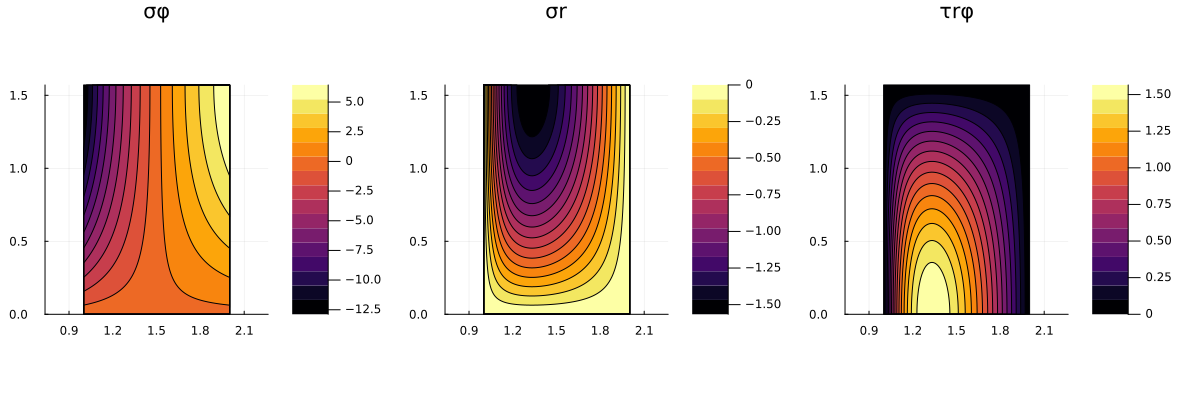

In [3]:
p1 = contourf(r_vals, φ_vals, σφ', title="σφ", aspect_ratio=1)
p2 = contourf(r_vals, φ_vals, σr', title="σr", aspect_ratio=1)
p3 = contourf(r_vals, φ_vals, τ', title="τrφ", aspect_ratio=1)

plot(p1, p2, p3, layout=(1, 3), size=(1200, 400))

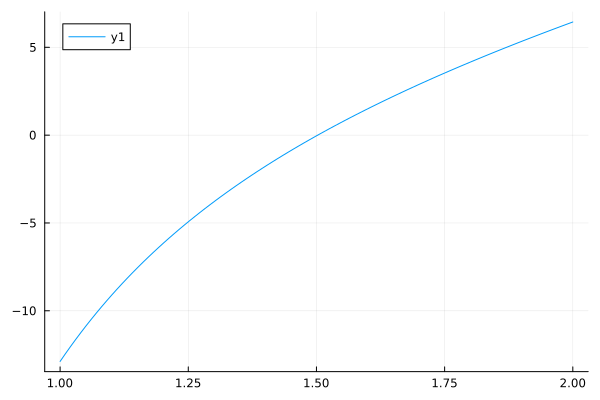

In [4]:
plot(r_vals, sigma_phi.(r_vals, π / 2))

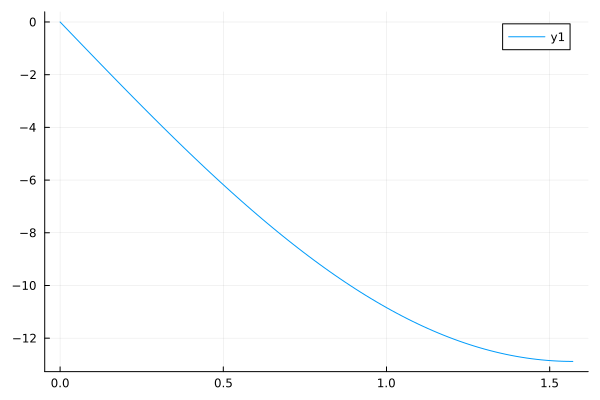

In [5]:
plot(φ_vals, sigma_phi.(a, φ_vals))

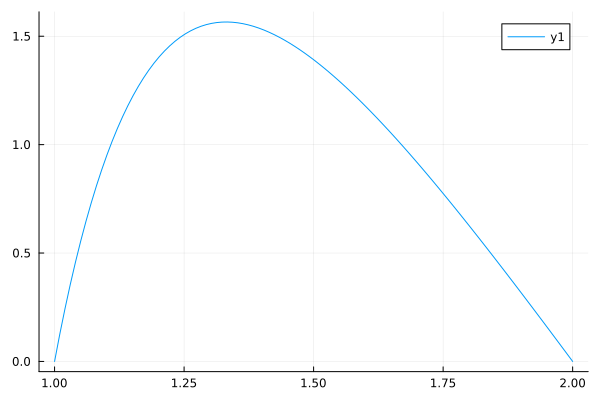

In [6]:
plot(r_vals, tau_rφ.(r_vals, 0))